In [32]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import ModelCheckpoint


In [33]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\all_fuels_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 

  ticker  commodity        date       open       high        low      close  \
0   CL=F  Crude Oil  2000-08-23  31.950001  32.799999  31.950001  32.049999   
1   CL=F  Crude Oil  2000-08-24  31.900000  32.240002  31.400000  31.629999   
2   CL=F  Crude Oil  2000-08-25  31.700001  32.099998  31.320000  32.049999   
3   CL=F  Crude Oil  2000-08-28  32.040001  32.919998  31.860001  32.869999   
4   CL=F  Crude Oil  2000-08-29  32.820000  33.029999  32.560001  32.720001   

   volume  
0   79385  
1   72978  
2   44601  
3   46770  
4   49131  


In [34]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(cat_cols)

Index(['ticker', 'commodity', 'date'], dtype='object')


In [35]:
num_cols = df.select_dtypes(include=['float', 'int64']).columns
print(num_cols)

Index(['open', 'high', 'low', 'close', 'volume'], dtype='object')


In [36]:
df['date'] = pd.to_datetime(df['date'])
# Trích xuất thêm thông tin từ ngày
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

In [37]:
# Chuẩn hóa các cột trong num_cols
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Kiểm tra kết quả
print(df.head())

  ticker  commodity       date      open      high       low     close  \
0   CL=F  Crude Oil 2000-08-23  0.287044  0.219795  0.391516  0.379293   
1   CL=F  Crude Oil 2000-08-24  0.286732  0.215984  0.388537  0.377007   
2   CL=F  Crude Oil 2000-08-25  0.285482  0.215031  0.388103  0.379293   
3   CL=F  Crude Oil 2000-08-28  0.287606  0.220612  0.391029  0.383757   
4   CL=F  Crude Oil 2000-08-29  0.292479  0.221361  0.394821  0.382941   

     volume  year  month  day  dayofweek  
0  0.034693  2000      8   23          2  
1  0.031893  2000      8   24          3  
2  0.019491  2000      8   25          4  
3  0.020439  2000      8   28          0  
4  0.021471  2000      8   29          1  


In [38]:
# Chuẩn bị dữ liệu
features = ['open', 'high', 'low', 'volume', 'year', 'month', 'day', 'dayofweek']
target = 'close'

# Chuẩn hóa các cột trong features và target
scaler = MinMaxScaler()
df[features + [target]] = scaler.fit_transform(df[features + [target]])


In [39]:
# Hàm tạo chuỗi dữ liệu theo cửa sổ thời gian
def create_sequences(data, features, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i + window_size][features].values)
        y.append(data.iloc[i + window_size][target])
    return np.array(X), np.array(y)

In [42]:
from tensorflow.keras.optimizers import Adam

def train_lstm_for_each_commodity(df, features, target, window_size=5, epochs=50, batch_size=32):
    results = {}
    models = {}  # Lưu trữ mô hình cho từng commodity
    commodities = df['commodity'].unique()

    for commodity in commodities:
        print(f"🔍 Đang xử lý commodity: {commodity}")
        
        # Lọc dữ liệu cho commodity
        commodity_data = df[df['commodity'] == commodity].sort_index()
        
        # Tạo chuỗi dữ liệu
        X, y = create_sequences(commodity_data, features, target, window_size)
        
        # Chia dữ liệu thành tập train (80%) và test (20%)
        split_index = int(len(X) * 0.8)
        X_train, X_test = X[:split_index], X[split_index:]
        y_train, y_test = y[:split_index], y[split_index:]
        
        # Xây dựng mô hình LSTM
        model = Sequential([
            InputLayer((window_size, len(features))),
            LSTM(128, return_sequences=True),
            Dropout(0.2),
            LSTM(64),
            Dense(32, activation='relu'),
            Dense(1, activation='linear')
        ])
        
        # Sử dụng Adam optimizer với learning rate = 0.0001
        optimizer = Adam(learning_rate=0.001)
        model.compile(optimizer=optimizer, loss='mean_squared_error')
        
        # Huấn luyện mô hình
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
        
        # Dự đoán trên tập test
        y_pred = model.predict(X_test)
        
        # Tính các độ lỗi
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Lưu kết quả
        results[commodity] = {
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        }
        
        # Lưu mô hình
        models[commodity] = model
        
        print(f"📌 Kết quả cho {commodity}:")
        print(f"   Mean Absolute Error (MAE): {mae:.4f}")
        print(f"   Mean Squared Error (MSE): {mse:.4f}")
        print(f"   Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"   R-squared (R²): {r2:.4f}")
    
    return results, models

In [43]:
# Huấn luyện mô hình và lưu kết quả
results, models = train_lstm_for_each_commodity(df, features, target, window_size)

🔍 Đang xử lý commodity: Crude Oil
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
📌 Kết quả cho Crude Oil:
   Mean Absolute Error (MAE): 0.0107
   Mean Squared Error (MSE): 0.0003
   Root Mean Squared Error (RMSE): 0.0173
   R-squared (R²): 0.9769
🔍 Đang xử lý commodity: Heating Oil
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
📌 Kết quả cho Heating Oil:
   Mean Absolute Error (MAE): 0.0022
   Mean Squared Error (MSE): 0.0000
   Root Mean Squared Error (RMSE): 0.0024
   R-squared (R²): 0.7368
🔍 Đang xử lý commodity: Natural Gas
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
📌 Kết quả cho Natural Gas:
   Mean Absolute Error (MAE): 0.0021
   Mean Squared Error (MSE): 0.0000
   Root Mean Squared Error (RMSE): 0.0029
   R-squared (R²): 0.9180
🔍 Đang xử lý commodity: RBOB Gasoline
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
📌 Kết quả cho RBOB Gasoline:
   Mean Absolute Error (MAE): 0.0022
   Mean Squared Error (MSE): 0.0000
   Root Mean Squared Error (RMSE): 0.0023
   R-squared (R²): 0.6405
🔍 Đang xử lý commodity: 

📊 Vẽ biểu đồ cho commodity: Crude Oil
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


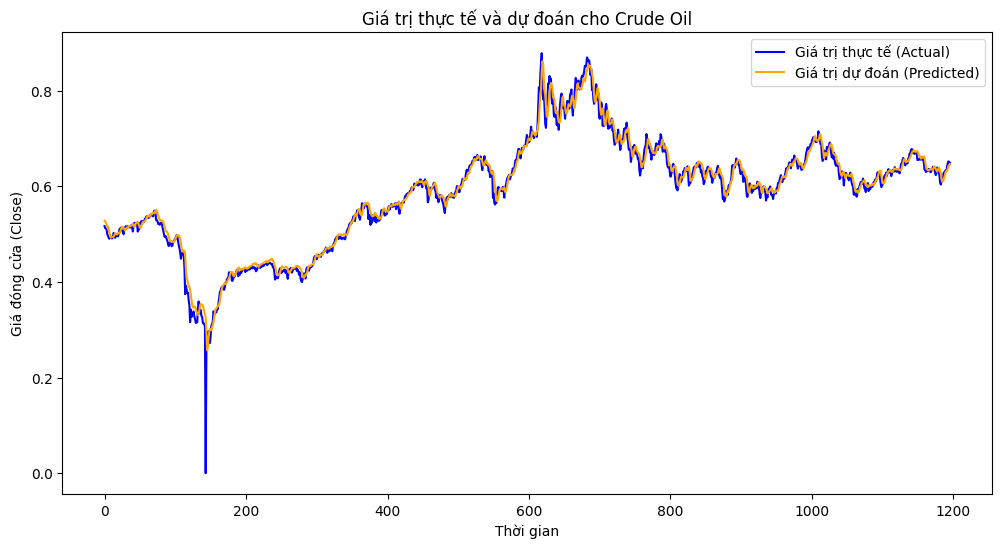

📊 Vẽ biểu đồ cho commodity: Heating Oil
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


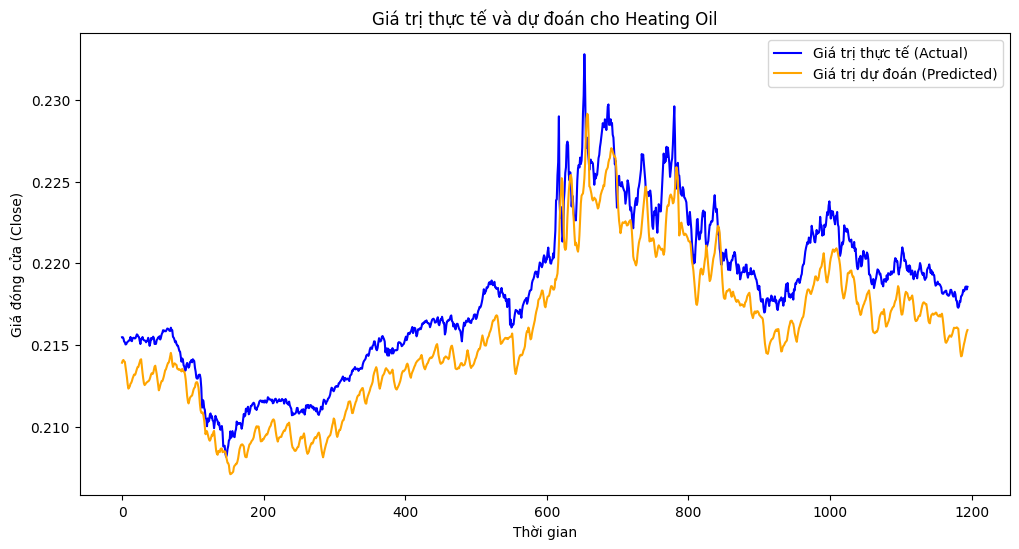

📊 Vẽ biểu đồ cho commodity: Natural Gas
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


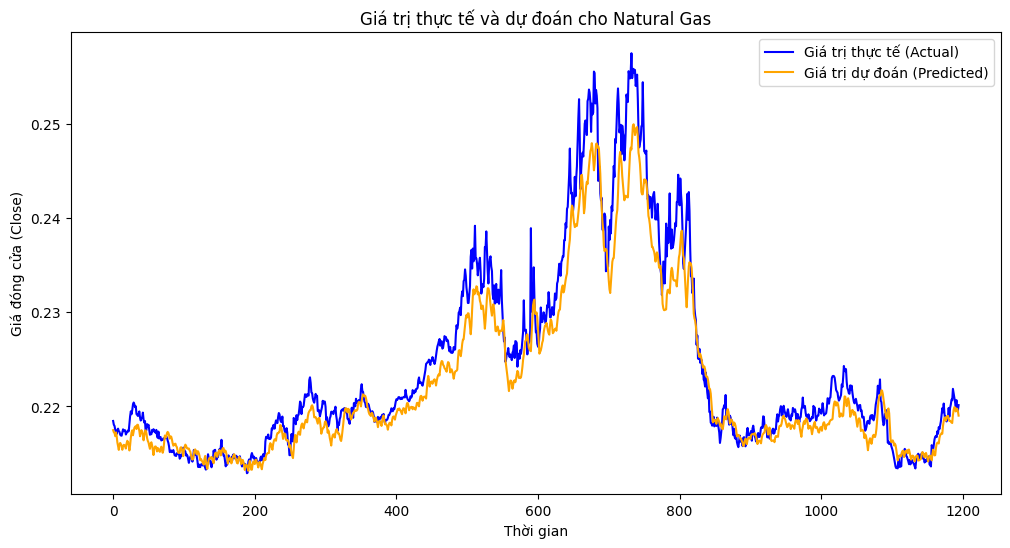

📊 Vẽ biểu đồ cho commodity: RBOB Gasoline
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


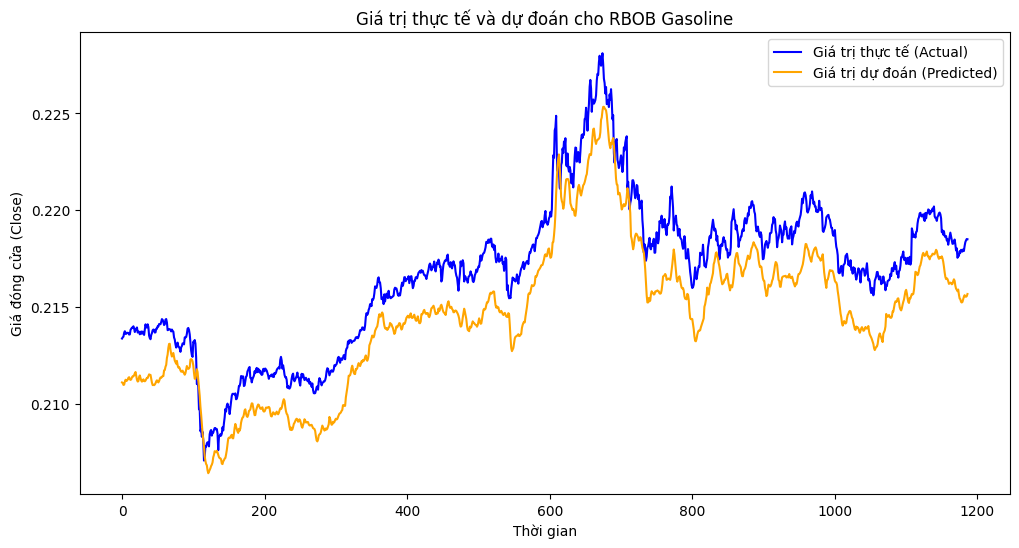

📊 Vẽ biểu đồ cho commodity: Brent Crude Oil
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


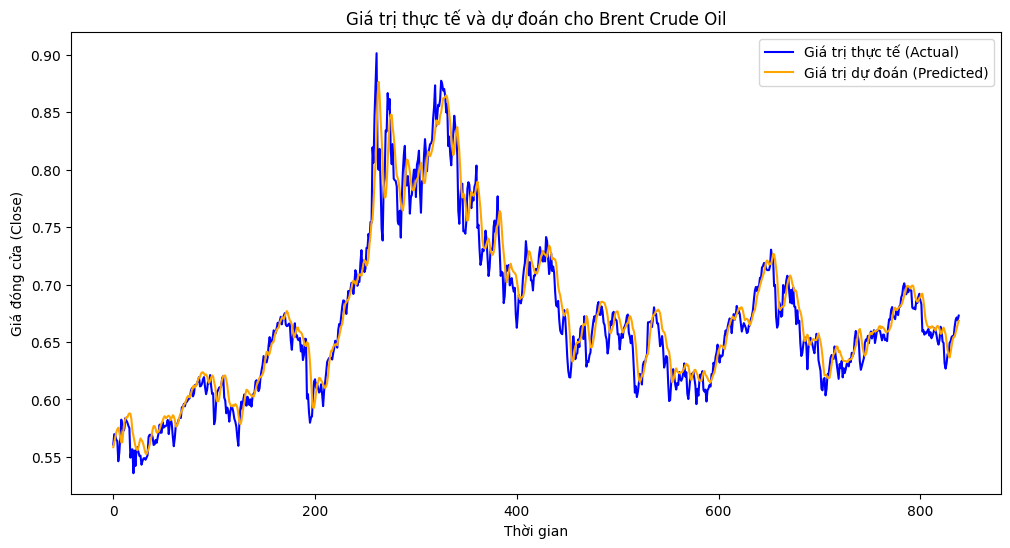

In [44]:
# Vẽ biểu đồ
def plot_predictions_for_each_commodity(df, features, target, window_size, models):
    """
    Vẽ biểu đồ trực quan hóa giá trị thực tế và dự đoán cho từng commodity.
    """
    commodities = df['commodity'].unique()

    for commodity in commodities:
        print(f"📊 Vẽ biểu đồ cho commodity: {commodity}")
        
        # Lọc dữ liệu cho commodity
        commodity_data = df[df['commodity'] == commodity].sort_index()
        
        # Tạo chuỗi dữ liệu
        X, y = create_sequences(commodity_data, features, target, window_size)
        
        # Chia dữ liệu thành tập test (20%)
        split_index = int(len(X) * 0.8)
        X_test = X[split_index:]
        y_test = y[split_index:]
        
        # Lấy mô hình đã huấn luyện
        model = models[commodity]
        
        # Dự đoán trên tập test
        y_pred = model.predict(X_test)
        
        # Vẽ biểu đồ
        plt.figure(figsize=(12, 6))
        plt.plot(y_test, label='Giá trị thực tế (Actual)', color='blue')
        plt.plot(y_pred, label='Giá trị dự đoán (Predicted)', color='orange')
        plt.title(f"Giá trị thực tế và dự đoán cho {commodity}")
        plt.xlabel("Thời gian")
        plt.ylabel("Giá đóng cửa (Close)")
        plt.legend()
        plt.show()

# Gọi hàm vẽ biểu đồ
plot_predictions_for_each_commodity(df, features, target, window_size, models)

Cách2

In [45]:
def train_lstm_for_each_commodity(df, features, target, window_size=5, epochs=50, batch_size=32):
    results = {}
    models = {}  # Lưu trữ mô hình cho từng commodity
    commodities = df['commodity'].unique()

    for commodity in commodities:
        print(f"🔍 Đang xử lý commodity: {commodity}")
        
        # Lọc dữ liệu cho commodity
        commodity_data = df[df['commodity'] == commodity].sort_index()
        
        # Tạo chuỗi dữ liệu
        X, y = create_sequences(commodity_data, features, target, window_size)
        
        # Chia dữ liệu thành tập train (80%) và test (20%)
        split_index = int(len(X) * 0.8)
        X_train, X_test = X[:split_index], X[split_index:]
        y_train, y_test = y[:split_index], y[split_index:]
        
        # Xây dựng mô hình LSTM
        model = Sequential([
            InputLayer((window_size, len(features))),
            LSTM(128, return_sequences=True),
            Dropout(0.2),
            LSTM(64),
            Dense(32, activation='relu'),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer='adam', loss='mean_squared_error')
        
        # Huấn luyện mô hình
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
        
        # Dự đoán trên tập test
        y_pred = model.predict(X_test)
        
        # Tính các độ lỗi
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Lưu kết quả
        results[commodity] = {
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        }
        
        # Lưu mô hình
        models[commodity] = model
        
        print(f"📌 Kết quả cho {commodity}:")
        print(f"   Mean Absolute Error (MAE): {mae:.4f}")
        print(f"   Mean Squared Error (MSE): {mse:.4f}")
        print(f"   Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"   R-squared (R²): {r2:.4f}")
    
    return results, models

In [46]:
# Huấn luyện mô hình và lưu kết quả
results, models = train_lstm_for_each_commodity(df, features, target, window_size)

🔍 Đang xử lý commodity: Crude Oil
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
📌 Kết quả cho Crude Oil:
   Mean Absolute Error (MAE): 0.0106
   Mean Squared Error (MSE): 0.0003
   Root Mean Squared Error (RMSE): 0.0170
   R-squared (R²): 0.9777
🔍 Đang xử lý commodity: Heating Oil
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
📌 Kết quả cho Heating Oil:
   Mean Absolute Error (MAE): 0.0006
   Mean Squared Error (MSE): 0.0000
   Root Mean Squared Error (RMSE): 0.0009
   R-squared (R²): 0.9615
🔍 Đang xử lý commodity: Natural Gas
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
📌 Kết quả cho Natural Gas:
   Mean Absolute Error (MAE): 0.0017
   Mean Squared Error (MSE): 0.0000
   Root Mean Squared Error (RMSE): 0.0021
   R-squared (R²): 0.9568
🔍 Đang xử lý commodity: RBOB Gasoline
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
📌 Kết quả cho RBOB Gasoline:
   Mean Absolute Error (MAE): 0.0005
   Mean Squared Error (MSE): 0.0000
   Root Mean Squared Error (RMSE): 0.0007
   R-squared (R²): 0.9662
🔍 Đang xử lý commodity: 

📊 Vẽ biểu đồ cho commodity: Crude Oil
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


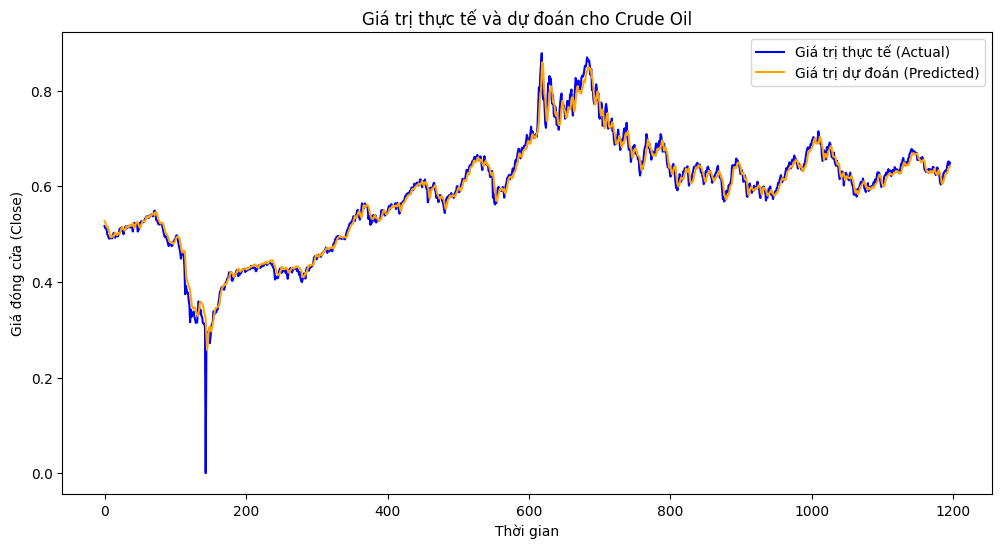

📊 Vẽ biểu đồ cho commodity: Heating Oil
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


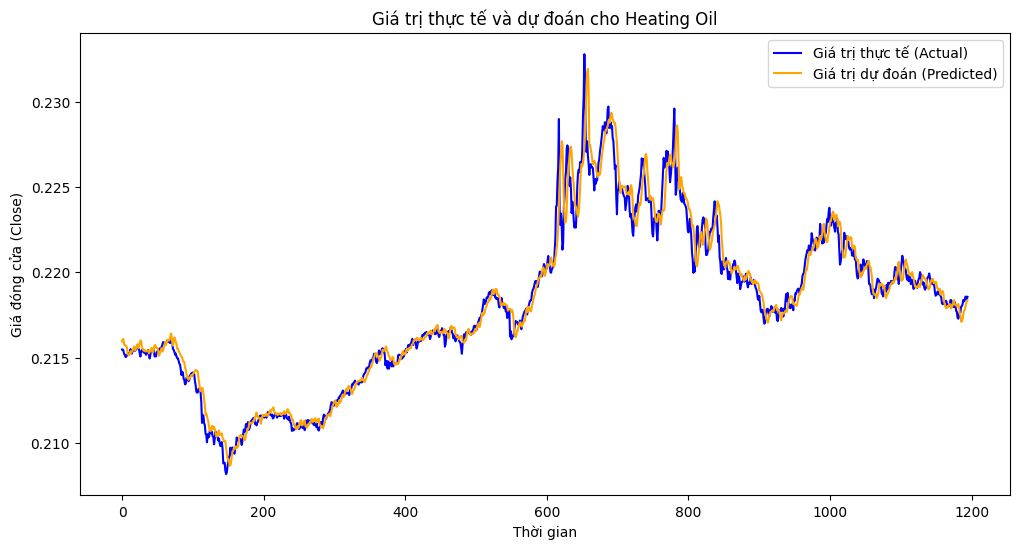

📊 Vẽ biểu đồ cho commodity: Natural Gas
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


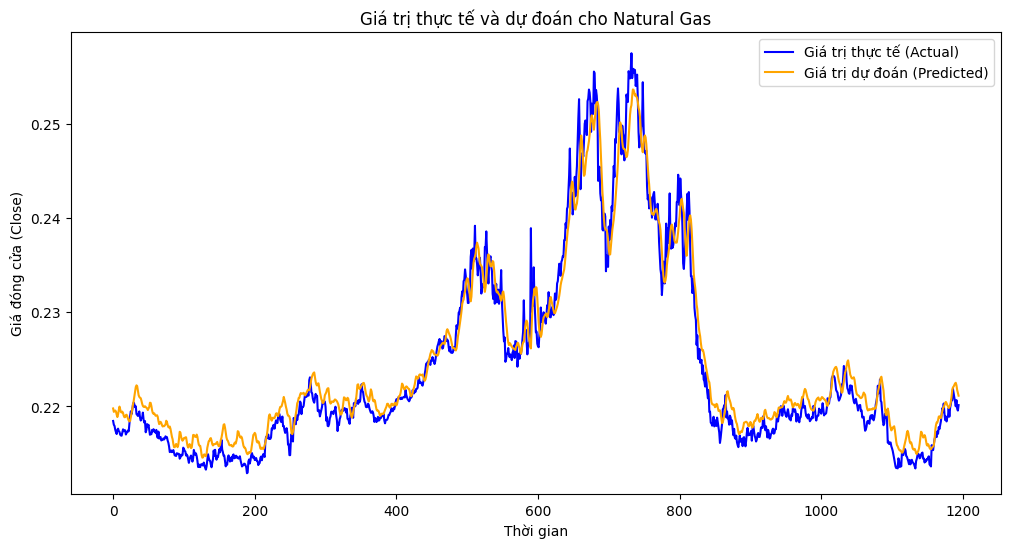

📊 Vẽ biểu đồ cho commodity: RBOB Gasoline
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


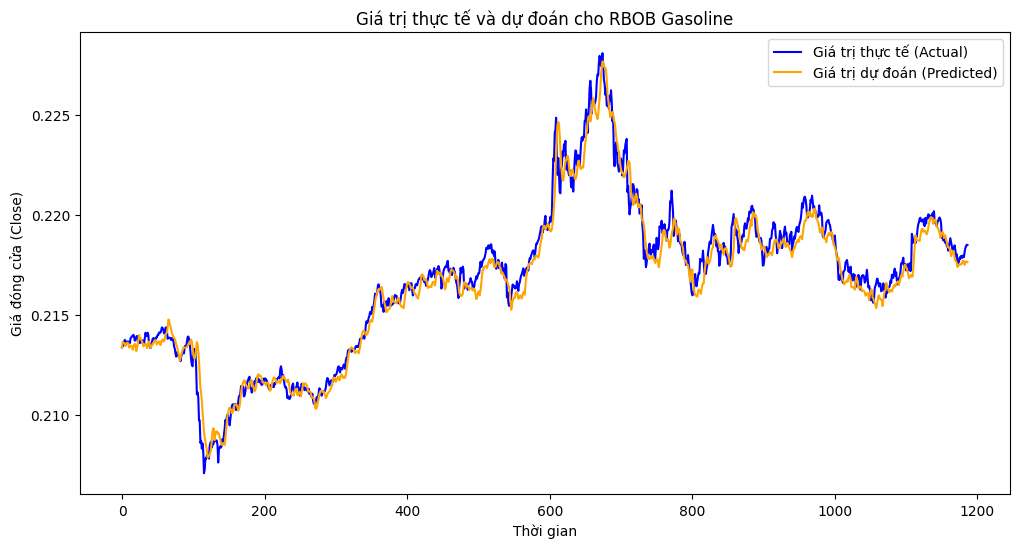

📊 Vẽ biểu đồ cho commodity: Brent Crude Oil
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


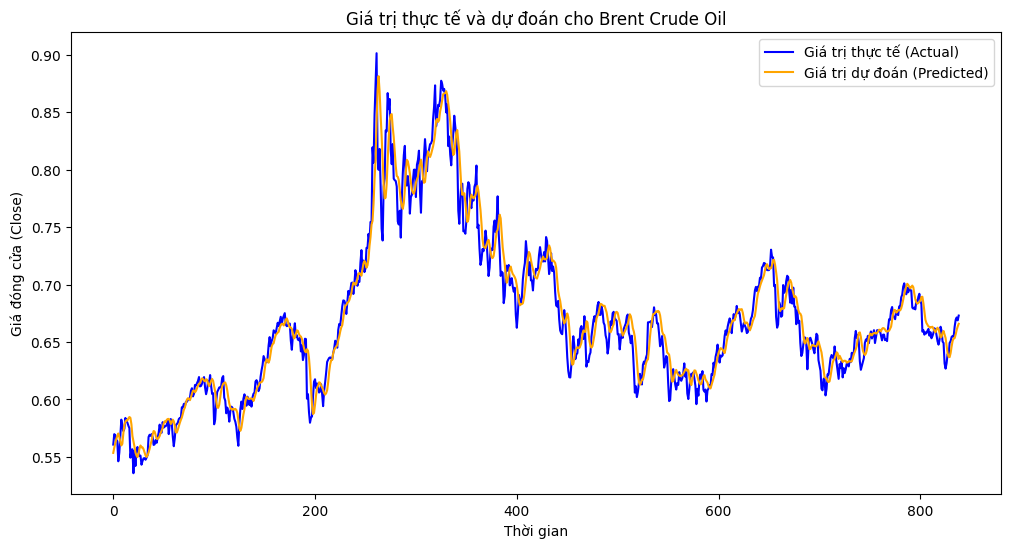

In [47]:
# Vẽ biểu đồ
def plot_predictions_for_each_commodity(df, features, target, window_size, models):
    """
    Vẽ biểu đồ trực quan hóa giá trị thực tế và dự đoán cho từng commodity.
    """
    commodities = df['commodity'].unique()

    for commodity in commodities:
        print(f"📊 Vẽ biểu đồ cho commodity: {commodity}")
        
        # Lọc dữ liệu cho commodity
        commodity_data = df[df['commodity'] == commodity].sort_index()
        
        # Tạo chuỗi dữ liệu
        X, y = create_sequences(commodity_data, features, target, window_size)
        
        # Chia dữ liệu thành tập test (20%)
        split_index = int(len(X) * 0.8)
        X_test = X[split_index:]
        y_test = y[split_index:]
        
        # Lấy mô hình đã huấn luyện
        model = models[commodity]
        
        # Dự đoán trên tập test
        y_pred = model.predict(X_test)
        
        # Vẽ biểu đồ
        plt.figure(figsize=(12, 6))
        plt.plot(y_test, label='Giá trị thực tế (Actual)', color='blue')
        plt.plot(y_pred, label='Giá trị dự đoán (Predicted)', color='orange')
        plt.title(f"Giá trị thực tế và dự đoán cho {commodity}")
        plt.xlabel("Thời gian")
        plt.ylabel("Giá đóng cửa (Close)")
        plt.legend()
        plt.show()

# Gọi hàm vẽ biểu đồ
plot_predictions_for_each_commodity(df, features, target, window_size, models)